# Goal:

The goal of this project is to understand "What increases the probability of winning a match?”

In [1]:
#import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Loading in EPL 2023/24 match results
path = r"C:\Users\jahg9\OneDrive\Documents\Data Analysis Projects\EPL Match Prediction\matches.csv"
epl = pd.read_csv(path)

# EDA

In [3]:
epl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 760 entries, 0 to 759
Data columns (total 28 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    760 non-null    int64  
 1   Date          760 non-null    object 
 2   Time          760 non-null    object 
 3   Comp          760 non-null    object 
 4   Round         760 non-null    object 
 5   Day           760 non-null    object 
 6   Venue         760 non-null    object 
 7   Result        760 non-null    object 
 8   GF            760 non-null    int64  
 9   GA            760 non-null    int64  
 10  Opponent      760 non-null    object 
 11  xG            760 non-null    float64
 12  xGA           760 non-null    float64
 13  Poss          760 non-null    float64
 14  Attendance    760 non-null    float64
 15  Captain       760 non-null    object 
 16  Formation     760 non-null    object 
 17  Referee       760 non-null    object 
 18  Match Report  760 non-null    

In [4]:
epl.describe()

,Unnamed: 0,GF,GA,xG,xGA,Poss,Attendance,Notes,Sh,SoT,Dist,FK,PK,PKatt,Season
count,760.000000,760.000000,760.000000,760.000000,760.000000,760.0000,760.000000,0.0,760.000000,760.000000,760.000000,760.000000,760.000000,760.000000,760.0
mean,24.051316,1.639474,1.639474,1.550263,1.550263,50.0000,38613.313158,NaN,13.660526,4.668421,16.711842,0.372368,0.126316,0.140789,2024.0
std,14.518127,1.331297,1.331297,0.891314,0.891314,13.7495,17952.911952,NaN,6.058391,2.645612,2.856164,0.598218,0.359097,0.377104,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,18.0000,10290.000000,NaN,1.000000,0.000000,7.000000,0.000000,0.000000,0.000000,2024.0
25%,11.750000,1.000000,1.000000,0.900000,0.900000,40.0000,24444.750000,NaN,9.000000,3.000000,14.900000,0.000000,0.000000,0.000000,2024.0
50%,24.000000,1.000000,1.000000,1.400000,1.400000,50.0000,38181.000000,NaN,13.000000,4.000000,16.700000,0.000000,0.000000,0.000000,2024.0
75%,36.000000,2.000000,2.000000,2.100000,2.100000,60.0000,53371.750000,NaN,17.000000,6.000000,18.400000,1.000000,0.000000,0.000000,2024.0
max,57.000000,8.000000,8.000000,7.000000,7.000000,82.0000,73612.000000,NaN,36.000000,15.000000,39.900000,3.000000,2.000000,2.000000,2024.0


In [5]:
epl.columns

Index(['Unnamed: 0', 'Date', 'Time', 'Comp', 'Round', 'Day', 'Venue', 'Result',
       'GF', 'GA', 'Opponent', 'xG', 'xGA', 'Poss', 'Attendance', 'Captain',
       'Formation', 'Referee', 'Match Report', 'Notes', 'Sh', 'SoT', 'Dist',
       'FK', 'PK', 'PKatt', 'Season', 'Team'],
      dtype='object')

In [6]:
epl.shape

(760, 28)

In [7]:
epl.drop(columns=['Unnamed: 0', 'Notes'], inplace=True)

In [8]:
epl.head()

,Date,Time,Comp,Round,Day,Venue,Result,GF,GA,Opponent,...,Referee,Match Report,Sh,SoT,Dist,FK,PK,PKatt,Season,Team
0,2023-08-11,20:00,Premier League,Matchweek 1,Fri,Away,W,3,0,Burnley,...,Craig Pawson,Match Report,17.0,8.0,13.9,0.0,0,0,2024,ManchesterCity
1,2023-08-19,20:00,Premier League,Matchweek 2,Sat,Home,W,1,0,Newcastle Utd,...,Robert Jones,Match Report,14.0,4.0,17.9,0.0,0,0,2024,ManchesterCity
2,2023-08-27,14:00,Premier League,Matchweek 3,Sun,Away,W,2,1,Sheffield Utd,...,Jarred Gillett,Match Report,29.0,9.0,17.3,2.0,0,1,2024,ManchesterCity
3,2023-09-02,15:00,Premier League,Matchweek 4,Sat,Home,W,5,1,Fulham,...,Michael Oliver,Match Report,6.0,4.0,14.8,0.0,1,1,2024,ManchesterCity
4,2023-09-16,15:00,Premier League,Matchweek 5,Sat,Away,W,3,1,West Ham,...,Andy Madley,Match Report,29.0,13.0,16.4,1.0,0,0,2024,ManchesterCity


In [9]:
epl['Team'].unique()

array(['ManchesterCity', 'Arsenal', 'Liverpool', 'AstonVilla',
       'TottenhamHotspur', 'Chelsea', 'NewcastleUnited',
       'ManchesterUnited', 'WestHamUnited', 'CrystalPalace',
       'BrightonandHoveAlbion', 'Bournemouth', 'Fulham',
       'WolverhamptonWanderers', 'Everton', 'Brentford',
       'NottinghamForest', 'LutonTown', 'Burnley', 'SheffieldUnited'],
      dtype=object)

# Creating Features

In [10]:
#Creating goal difference column
epl['GD'] = epl['GF'] - epl['GA']
#Creating expected goal difference column
epl['xGD'] = epl['xG'] - epl['xGA']
# Encode wins as a 1
epl['win'] = (epl['Result'] == 'W').astype(int)

In [11]:
epl['Date'] = pd.to_datetime(epl['Date']).dt.date
epl['Time'] = epl['Time'].str.strip()
epl['Referee'] = epl['Referee'].str.strip()

epl.head()



,Date,Time,Comp,Round,Day,Venue,Result,GF,GA,Opponent,...,SoT,Dist,FK,PK,PKatt,Season,Team,GD,xGD,win
0,2023-08-11,20:00,Premier League,Matchweek 1,Fri,Away,W,3,0,Burnley,...,8.0,13.9,0.0,0,0,2024,ManchesterCity,3,1.6,1
1,2023-08-19,20:00,Premier League,Matchweek 2,Sat,Home,W,1,0,Newcastle Utd,...,4.0,17.9,0.0,0,0,2024,ManchesterCity,1,0.7,1
2,2023-08-27,14:00,Premier League,Matchweek 3,Sun,Away,W,2,1,Sheffield Utd,...,9.0,17.3,2.0,0,1,2024,ManchesterCity,1,2.8,1
3,2023-09-02,15:00,Premier League,Matchweek 4,Sat,Home,W,5,1,Fulham,...,4.0,14.8,0.0,1,1,2024,ManchesterCity,4,0.8,1
4,2023-09-16,15:00,Premier League,Matchweek 5,Sat,Away,W,3,1,West Ham,...,13.0,16.4,1.0,0,0,2024,ManchesterCity,2,2.7,1


In [12]:
epl_opp = epl[['Date', 'Time', 'Referee', 'Team', 'Sh', 'SoT', 'Venue']].copy()


#Rename the columns
epl_opp.columns = [
    'Date', 'Time', 'Referee',
    'Opponent', 'Opp_Sh', 'Opp_SoT', 'Venue'
]


# flip venue so Home matches Away and vice versa
epl_opp['Venue'] = epl_opp['Venue'].map({
    'Home': 'Away',
    'Away': 'Home'
})


In [13]:
epl_merged = epl.merge(
    epl_opp,
    on=['Date', 'Time', 'Referee', 'Venue'],
    how='left'
)

#Why did the shape change when including/excluding venue?

epl_merged.shape


(760, 32)

In [14]:
matchkey = ['Date', 'Time', 'Referee', 'Venue']

epl_merged.groupby(matchkey).size().value_counts()


1    760
Name: count, dtype: int64

In [15]:
epl_merged.head()

,Date,Time,Comp,Round,Day,Venue,Result,GF,GA,Opponent_x,...,PK,PKatt,Season,Team,GD,xGD,win,Opponent_y,Opp_Sh,Opp_SoT
0,2023-08-11,20:00,Premier League,Matchweek 1,Fri,Away,W,3,0,Burnley,...,0,0,2024,ManchesterCity,3,1.6,1,Burnley,6.0,1.0
1,2023-08-19,20:00,Premier League,Matchweek 2,Sat,Home,W,1,0,Newcastle Utd,...,0,0,2024,ManchesterCity,1,0.7,1,NewcastleUnited,7.0,1.0
2,2023-08-27,14:00,Premier League,Matchweek 3,Sun,Away,W,2,1,Sheffield Utd,...,0,1,2024,ManchesterCity,1,2.8,1,SheffieldUnited,6.0,1.0
3,2023-09-02,15:00,Premier League,Matchweek 4,Sat,Home,W,5,1,Fulham,...,1,1,2024,ManchesterCity,4,0.8,1,Fulham,6.0,4.0
4,2023-09-16,15:00,Premier League,Matchweek 5,Sat,Away,W,3,1,West Ham,...,0,0,2024,ManchesterCity,2,2.7,1,WestHamUnited,6.0,3.0


In [16]:
# Compute shot difference (team shots minus opponent shots)
epl_merged['shot_diff'] = epl_merged['Sh'] - epl_merged['Opp_Sh']

# Compute shots-on-target difference
epl_merged['sot_diff'] = epl_merged['SoT'] - epl_merged['Opp_SoT']


In [17]:
epl_merged.head()


,Date,Time,Comp,Round,Day,Venue,Result,GF,GA,Opponent_x,...,Season,Team,GD,xGD,win,Opponent_y,Opp_Sh,Opp_SoT,shot_diff,sot_diff
0,2023-08-11,20:00,Premier League,Matchweek 1,Fri,Away,W,3,0,Burnley,...,2024,ManchesterCity,3,1.6,1,Burnley,6.0,1.0,11.0,7.0
1,2023-08-19,20:00,Premier League,Matchweek 2,Sat,Home,W,1,0,Newcastle Utd,...,2024,ManchesterCity,1,0.7,1,NewcastleUnited,7.0,1.0,7.0,3.0
2,2023-08-27,14:00,Premier League,Matchweek 3,Sun,Away,W,2,1,Sheffield Utd,...,2024,ManchesterCity,1,2.8,1,SheffieldUnited,6.0,1.0,23.0,8.0
3,2023-09-02,15:00,Premier League,Matchweek 4,Sat,Home,W,5,1,Fulham,...,2024,ManchesterCity,4,0.8,1,Fulham,6.0,4.0,0.0,0.0
4,2023-09-16,15:00,Premier League,Matchweek 5,Sat,Away,W,3,1,West Ham,...,2024,ManchesterCity,2,2.7,1,WestHamUnited,6.0,3.0,23.0,10.0


# Confirming Merge Worked

In [18]:
epl_merged.groupby(['Date', 'Time', 'Referee'])['sot_diff'].sum()


Date        Time   Referee       
2023-08-11  20:00  Craig Pawson      0.0
2023-08-12  12:30  Michael Oliver    0.0
            15:00  David Coote       0.0
                   John Brooks       0.0
                   Peter Bankes      0.0
                                    ... 
2024-05-19  16:00  Graham Scott      0.0
                   John Brooks       0.0
                   Matt Donohue      0.0
                   Michael Oliver    0.0
                   Simon Hooper      0.0
Name: sot_diff, Length: 380, dtype: float64

In [19]:
epl_merged.head()

,Date,Time,Comp,Round,Day,Venue,Result,GF,GA,Opponent_x,...,Season,Team,GD,xGD,win,Opponent_y,Opp_Sh,Opp_SoT,shot_diff,sot_diff
0,2023-08-11,20:00,Premier League,Matchweek 1,Fri,Away,W,3,0,Burnley,...,2024,ManchesterCity,3,1.6,1,Burnley,6.0,1.0,11.0,7.0
1,2023-08-19,20:00,Premier League,Matchweek 2,Sat,Home,W,1,0,Newcastle Utd,...,2024,ManchesterCity,1,0.7,1,NewcastleUnited,7.0,1.0,7.0,3.0
2,2023-08-27,14:00,Premier League,Matchweek 3,Sun,Away,W,2,1,Sheffield Utd,...,2024,ManchesterCity,1,2.8,1,SheffieldUnited,6.0,1.0,23.0,8.0
3,2023-09-02,15:00,Premier League,Matchweek 4,Sat,Home,W,5,1,Fulham,...,2024,ManchesterCity,4,0.8,1,Fulham,6.0,4.0,0.0,0.0
4,2023-09-16,15:00,Premier League,Matchweek 5,Sat,Away,W,3,1,West Ham,...,2024,ManchesterCity,2,2.7,1,WestHamUnited,6.0,3.0,23.0,10.0


In [20]:
epl_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 760 entries, 0 to 759
Data columns (total 34 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          760 non-null    object 
 1   Time          760 non-null    object 
 2   Comp          760 non-null    object 
 3   Round         760 non-null    object 
 4   Day           760 non-null    object 
 5   Venue         760 non-null    object 
 6   Result        760 non-null    object 
 7   GF            760 non-null    int64  
 8   GA            760 non-null    int64  
 9   Opponent_x    760 non-null    object 
 10  xG            760 non-null    float64
 11  xGA           760 non-null    float64
 12  Poss          760 non-null    float64
 13  Attendance    760 non-null    float64
 14  Captain       760 non-null    object 
 15  Formation     760 non-null    object 
 16  Referee       760 non-null    object 
 17  Match Report  760 non-null    object 
 18  Sh            760 non-null    

In [22]:
epl_merged[epl_merged['shot_diff'].isnull()]

,Date,Time,Comp,Round,Day,Venue,Result,GF,GA,Opponent_x,...,Season,Team,GD,xGD,win,Opponent_y,Opp_Sh,Opp_SoT,shot_diff,sot_diff


In [23]:
epl_merged.shape

(760, 34)

In [24]:
epl_merged.head()

,Date,Time,Comp,Round,Day,Venue,Result,GF,GA,Opponent_x,...,Season,Team,GD,xGD,win,Opponent_y,Opp_Sh,Opp_SoT,shot_diff,sot_diff
0,2023-08-11,20:00,Premier League,Matchweek 1,Fri,Away,W,3,0,Burnley,...,2024,ManchesterCity,3,1.6,1,Burnley,6.0,1.0,11.0,7.0
1,2023-08-19,20:00,Premier League,Matchweek 2,Sat,Home,W,1,0,Newcastle Utd,...,2024,ManchesterCity,1,0.7,1,NewcastleUnited,7.0,1.0,7.0,3.0
2,2023-08-27,14:00,Premier League,Matchweek 3,Sun,Away,W,2,1,Sheffield Utd,...,2024,ManchesterCity,1,2.8,1,SheffieldUnited,6.0,1.0,23.0,8.0
3,2023-09-02,15:00,Premier League,Matchweek 4,Sat,Home,W,5,1,Fulham,...,2024,ManchesterCity,4,0.8,1,Fulham,6.0,4.0,0.0,0.0
4,2023-09-16,15:00,Premier League,Matchweek 5,Sat,Away,W,3,1,West Ham,...,2024,ManchesterCity,2,2.7,1,WestHamUnited,6.0,3.0,23.0,10.0


# Encode result as a binary variable

In [25]:
epl_merged['win'] = (epl_merged['Result'] == 'W').astype(int)

## Data Plots

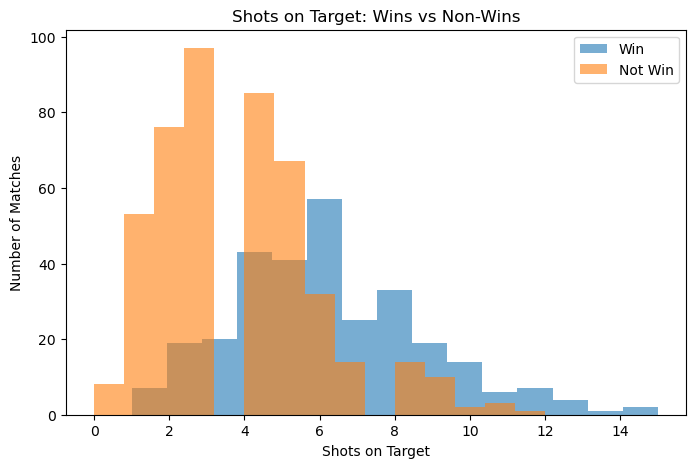

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    epl_merged.loc[epl_merged['win'] == 1, 'SoT'],
    bins=15,
    alpha=0.6,
    label='Win'
)

plt.hist(
    epl_merged.loc[epl_merged['win'] == 0, 'SoT'],
    bins=15,
    alpha=0.6,
    label='Not Win'
)

plt.xlabel('Shots on Target')
plt.ylabel('Number of Matches')
plt.title('Shots on Target: Wins vs Non-Wins')
plt.legend()

plt.show()


This histogram shows that as teams generate more shots on target, they are more likely to win matches vs teams that generate less shots on target. 

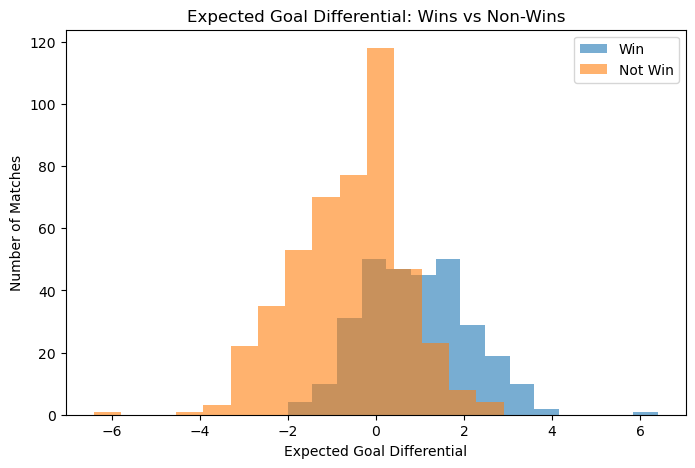

In [27]:
plt.figure(figsize=(8, 5))

plt.hist(
    epl_merged.loc[epl_merged['win'] == 1, 'xGD'],
    bins=15,
    alpha=0.6,
    label='Win'
)

plt.hist(
    epl_merged.loc[epl_merged['win'] == 0, 'xGD'],
    bins=15,
    alpha=0.6,
    label='Not Win'
)

plt.xlabel('Expected Goal Differential')
plt.ylabel('Number of Matches')
plt.title('Expected Goal Differential: Wins vs Non-Wins')
plt.legend()

plt.show()

The histogram shows a clear rightward shift in expected goal differential for wins versus non-wins, indicating that teams generating higher-quality chances than their opponents are substantially more likely to win, with overlap near zero reflecting inherent match randomness.

In [28]:
epl_merged.columns

Index(['Date', 'Time', 'Comp', 'Round', 'Day', 'Venue', 'Result', 'GF', 'GA',
       'Opponent_x', 'xG', 'xGA', 'Poss', 'Attendance', 'Captain', 'Formation',
       'Referee', 'Match Report', 'Sh', 'SoT', 'Dist', 'FK', 'PK', 'PKatt',
       'Season', 'Team', 'GD', 'xGD', 'win', 'Opponent_y', 'Opp_Sh', 'Opp_SoT',
       'shot_diff', 'sot_diff'],
      dtype='object')

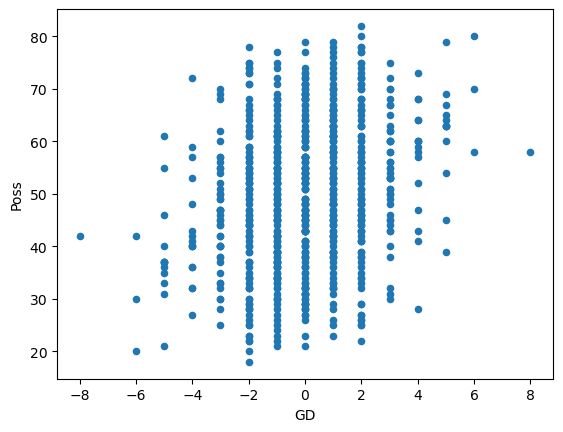

In [29]:
epl_merged.plot.scatter(x='GD', y='Poss')
plt.show()

The scatter plot shows that possession varies widely across all goal differences, indicating that possession alone is a weak predictor of match outcomes.

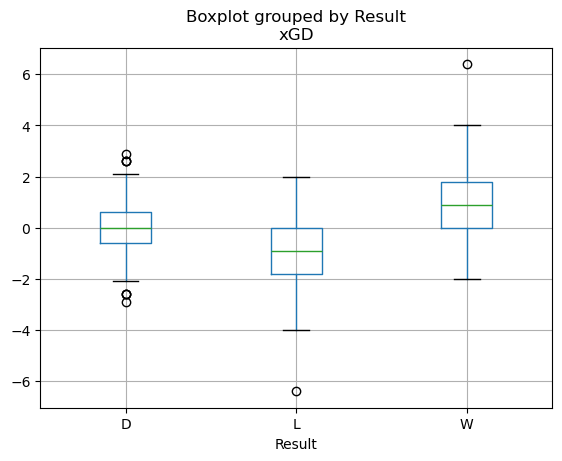

In [30]:
epl_merged.boxplot(column='xGD', by='Result')
plt.show()

Wins are associated with hgiher xGD on average than Draws and losses. The XGD median, min and maximum values are higher than losses and draws indicating that more expected goals gives a hgiher chance of winning a match. 

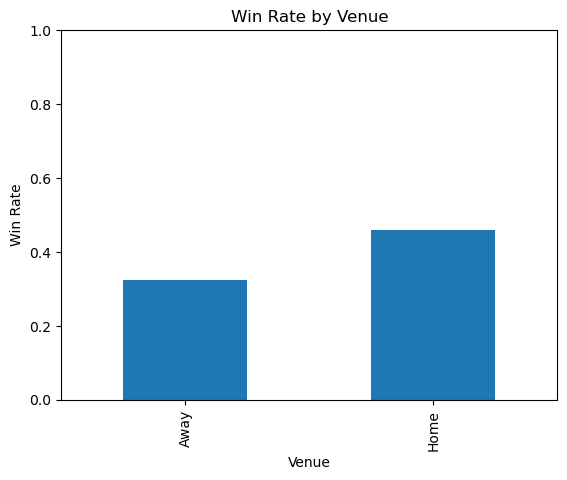

In [31]:
import matplotlib.pyplot as plt

win_rate = (
    epl_merged
    .groupby('Venue')['win']
    .mean()
)

win_rate.plot(kind='bar')

plt.ylabel('Win Rate')
plt.title('Win Rate by Venue')
plt.ylim(0, 1)
plt.show()



# Feature Selection

In [32]:
corr = epl_merged.select_dtypes(include='number').corr()
corr


,GF,GA,xG,xGA,Poss,Attendance,Sh,SoT,Dist,FK,PK,PKatt,Season,GD,xGD,win,Opp_Sh,Opp_SoT,shot_diff,sot_diff
GF,1.000000,-0.226569,0.596994,-0.229203,2.101021e-01,2.182512e-02,0.335197,0.605680,-0.093331,0.031480,0.288301,0.295440,NaN,7.831248e-01,5.118162e-01,0.655196,-0.232943,-0.241222,3.309014e-01,5.276840e-01
GA,-0.226569,1.000000,-0.229203,0.596994,-2.101021e-01,2.182512e-02,-0.232943,-0.241222,-0.001301,-0.019804,-0.034145,-0.040477,NaN,-7.831248e-01,-5.118162e-01,-0.564294,0.335197,0.605680,-3.309014e-01,-5.276840e-01
xG,0.596994,-0.229203,1.000000,-0.302896,3.611624e-01,1.112873e-01,0.697386,0.661852,-0.202132,0.077528,0.393010,0.449689,NaN,5.275005e-01,8.071232e-01,0.439397,-0.363625,-0.268935,6.179637e-01,5.799505e-01
xGA,-0.229203,0.596994,-0.302896,1.000000,-3.611624e-01,1.112873e-01,-0.363625,-0.268935,-0.004152,-0.047503,-0.076669,-0.087326,NaN,-5.275005e-01,-8.071232e-01,-0.402958,0.697386,0.661852,-6.179637e-01,-5.799505e-01
Poss,0.210102,-0.210102,0.361162,-0.361162,1.000000e+00,4.733245e-16,0.539015,0.377011,0.005002,0.076887,0.095531,0.111297,NaN,2.682868e-01,4.474687e-01,0.212814,-0.539015,-0.377011,6.278762e-01,4.698126e-01
Attendance,0.021825,0.021825,0.111287,0.111287,4.733245e-16,1.000000e+00,0.086697,0.076856,-0.011753,-0.016717,0.039580,0.052239,NaN,2.184371e-16,1.673746e-16,0.024741,0.086697,0.076856,1.685786e-16,1.916518e-16
Sh,0.335197,-0.232943,0.697386,-0.363625,5.390150e-01,8.669691e-02,1.000000,0.702934,0.005121,0.175611,0.073635,0.127058,NaN,3.627391e-01,6.572794e-01,0.292086,-0.473953,-0.336163,8.584734e-01,6.474358e-01
SoT,0.605680,-0.241222,0.661852,-0.268935,3.770111e-01,7.685576e-02,0.702934,1.000000,-0.038589,0.112249,0.094070,0.144578,NaN,5.407199e-01,5.766079e-01,0.437115,-0.336163,-0.287920,6.052005e-01,8.024712e-01
Dist,-0.093331,-0.001301,-0.202132,-0.004152,5.002255e-03,-1.175317e-02,0.005121,-0.038589,1.000000,0.220035,0.133164,0.137655,NaN,-5.875801e-02,-1.226455e-01,-0.021744,-0.036003,-0.046801,2.395163e-02,5.116940e-03
FK,0.031480,-0.019804,0.077528,-0.047503,7.688698e-02,-1.671716e-02,0.175611,0.112249,0.220035,1.000000,-0.029117,-0.010766,NaN,3.274342e-02,7.745485e-02,0.072284,-0.102853,-0.038430,1.621859e-01,9.388396e-02


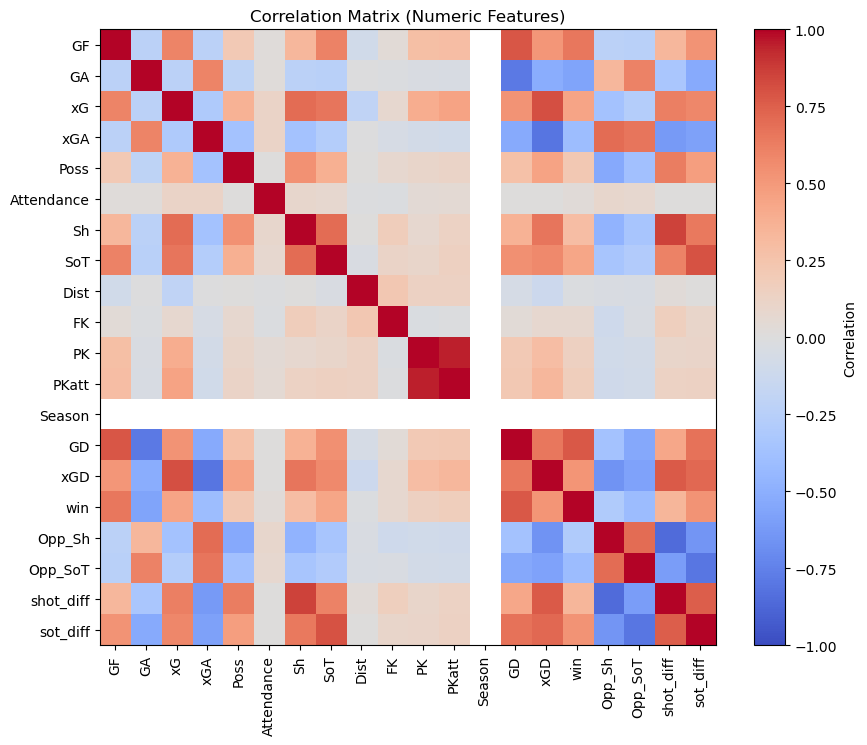

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title('Correlation Matrix (Numeric Features)')
plt.show()


In [34]:


win_corr = (
    epl_merged
    .select_dtypes(include='number')
    .corr()['win']
    .drop('win')
    .sort_values(ascending=False)
)

win_corr



GD            0.778605
GF            0.655196
sot_diff      0.526533
xGD           0.521826
xG            0.439397
SoT           0.437115
shot_diff     0.342229
Sh            0.292086
Poss          0.212814
PKatt         0.164804
PK            0.145379
FK            0.072284
Attendance    0.024741
Dist         -0.021744
Opp_Sh       -0.295502
xGA          -0.402958
Opp_SoT      -0.407940
GA           -0.564294
Season             NaN
Name: win, dtype: float64

In [35]:
from scipy.stats import pearsonr

r, p = pearsonr(epl_merged['xGD'], epl_merged['GD'])

r, p


(np.float64(0.6535563925503014), np.float64(8.860503156200417e-94))

In [36]:
#Due to all of these variables being in match and leading to data leakage, the best approach is to use rolling variables to predict wins. 
# Rolling variables will be using the averages of the previous games prior to the match being predicted


In [37]:
rolling_features = [
    'GF', 'GA', 'GD',        # goal form
    'xG', 'xGA', 'xGD',      # xG form
    'SoT', 'Sh',              # shot form
    'Poss',                   # possession form
]

# for each feature, compute rolling mean grouped by team
# critically: shift(1) so current match is excluded

In [38]:
# step 1: add rolling versions first
for col in ['GF', 'GA', 'GD', 'xG', 'xGA', 'xGD', 'SoT', 'Sh', 'Poss']:
    epl_merged[f'rolling_{col}'] = (
        epl_merged.groupby('Team')[col]
        .transform(lambda x: x.shift(1).rolling(5).mean())
    )

# step 2: then drop the raw columns
drop_cols = ['GF', 'GA', 'GD', 'xG', 'xGA', 'xGD', 
             'SoT', 'Sh', 'sot_diff', 'shot_diff', 
             'Opp_Sh', 'Opp_SoT', 'PK', 'PKatt']

epl_merged = epl_merged.drop(columns=drop_cols)

In [39]:
epl_merged.head(20)

,Date,Time,Comp,Round,Day,Venue,Result,Opponent_x,Poss,Attendance,...,Opponent_y,rolling_GF,rolling_GA,rolling_GD,rolling_xG,rolling_xGA,rolling_xGD,rolling_SoT,rolling_Sh,rolling_Poss
0,2023-08-11,20:00,Premier League,Matchweek 1,Fri,Away,W,Burnley,65.0,21572.0,...,Burnley,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-08-19,20:00,Premier League,Matchweek 2,Sat,Home,W,Newcastle Utd,59.0,53419.0,...,NewcastleUnited,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2023-08-27,14:00,Premier League,Matchweek 3,Sun,Away,W,Sheffield Utd,79.0,31336.0,...,SheffieldUnited,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2023-09-02,15:00,Premier League,Matchweek 4,Sat,Home,W,Fulham,68.0,52899.0,...,Fulham,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2023-09-16,15:00,Premier League,Matchweek 5,Sat,Away,W,West Ham,68.0,62475.0,...,WestHamUnited,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2023-09-23,15:00,Premier League,Matchweek 6,Sat,Home,W,Nott'ham Forest,57.0,53413.0,...,NottinghamForest,2.8,0.6,2.2,2.44,0.72,1.72,7.6,19.0,67.8
6,2023-09-30,15:00,Premier League,Matchweek 7,Sat,Away,L,Wolves,68.0,31415.0,...,WolverhamptonWanderers,2.6,0.6,2.0,2.32,0.86,1.46,6.8,17.0,66.2
7,2023-10-08,16:30,Premier League,Matchweek 8,Sun,Away,L,Arsenal,51.0,60233.0,...,Arsenal,2.6,1.0,1.6,2.30,0.88,1.42,7.6,18.8,68.0
8,2023-10-21,15:00,Premier League,Matchweek 9,Sat,Home,W,Brighton,55.0,53466.0,...,BrightonandHoveAlbion,2.2,1.0,1.2,1.70,0.82,0.88,5.8,13.8,62.4
9,2023-10-29,15:30,Premier League,Matchweek 10,Sun,Away,W,Manchester Utd,60.0,73502.0,...,ManchesterUnited,1.6,1.0,0.6,1.42,0.70,0.72,6.0,14.6,59.8


In [40]:
epl_merged.to_csv("epl_merged.csv", index=False)